# GeoPandas — praktyczny przewodnik: od podstaw po analizy przestrzenne (z odpowiednikami narzędzi QGIS)

`GeoDataFrame` to `pandas.DataFrame` z dodatkową kolumną `geometry`
(obiekty `shapely`) i CRS. Cała reszta API pandas (`.groupby`, `.merge`,
boolean indexing) działa bez zmian — notebook skupia się na tym, co jest
**specyficznie przestrzenne**, z odniesieniem do narzędzi QGIS, które te
same operacje wykonują ręcznie z poziomu GUI.

**Instalacja:**
```
pip install geopandas pyogrio mapclassify
```
`pyogrio` — szybszy silnik I/O niż domyślny `fiona`. `mapclassify` —
wymagany do `.explore()`/klasyfikacji kolorów.

In [1]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon, box

print("GeoPandas", gpd.__version__, "| silnik I/O:", gpd.options.io_engine)

GeoPandas 1.1.4 | silnik I/O: None


## Dane demo

Syntetyczne warstwy przybliżające realny projekt: warstwa poligonowa
"gminy" (z polami do agregacji/dissolve), druga warstwa poligonowa
"strefy" częściowo nachodząca na gminy (do operacji overlay), warstwa
punktowa z CSV (z wartością liczbową do agregacji) i osobna tabela
atrybutów bez geometrii (do złączenia nieprzestrzennego).

In [2]:
dane_dir = Path("geo_demo")
dane_dir.mkdir(exist_ok=True)

gminy = gpd.GeoDataFrame(
    {
        "nazwa": ["Srodmiescie", "Mokotow", "Wola", "Praga-Poludnie", "Ursynow", "Bielany"],
        "wojewodztwo": ["mazowieckie"] * 6,
        "ludnosc": [130000, 220000, 140000, 190000, 150000, 130000],
    },
    geometry=[
        box(21.00, 52.22, 21.03, 52.25),
        box(21.00, 52.17, 21.05, 52.22),
        box(20.95, 52.22, 21.00, 52.26),
        box(21.03, 52.20, 21.10, 52.25),
        box(21.00, 52.12, 21.06, 52.17),
        box(20.92, 52.26, 20.98, 52.30),
    ],
    crs="EPSG:4326",
)

# druga warstwa poligonowa, celowo nachodząca na granice gmin — do overlay (sekcja 7)
strefy = gpd.GeoDataFrame(
    {"strefa": ["ochrony_A", "inwestycyjna_B", "zielona_C"]},
    geometry=[
        box(20.98, 52.20, 21.06, 52.24),
        box(21.02, 52.18, 21.09, 52.23),
        box(20.90, 52.24, 21.02, 52.28),
    ],
    crs="EPSG:4326",
)

rng = np.random.default_rng(0)
n = 400
lokalizacje_csv = pd.DataFrame({
    "id_punktu": range(1, n + 1),
    "nazwa": [f"Punkt {i}" for i in range(1, n + 1)],
    "lon": rng.uniform(20.90, 21.10, n),
    "lat": rng.uniform(52.12, 52.30, n),
    "kategoria": rng.choice(["sklep", "magazyn", "biuro"], n),
    "wartosc_sprzedazy": rng.gamma(shape=2.0, scale=500, size=n).round(2),
})

# tabela wyłącznie atrybutowa (bez geometrii) — do złączenia nieprzestrzennego w sekcji 8b
opisy_kategorii = pd.DataFrame({
    "kategoria": ["sklep", "magazyn", "biuro"],
    "opis": ["punkt sprzedaży detalicznej", "magazyn/centrum dystrybucji", "biuro administracyjne"],
    "stawka_podatku": [0.19, 0.08, 0.19],
})

gminy.to_file(dane_dir / "gminy.shp")
gminy.to_file(dane_dir / "warstwy.gpkg", layer="gminy", driver="GPKG")
strefy.to_file(dane_dir / "warstwy.gpkg", layer="strefy", driver="GPKG")
lokalizacje_csv.to_csv(dane_dir / "lokalizacje.csv", index=False)

sorted(p.name for p in dane_dir.iterdir())

/tmp/ipykernel_158/3602615481.py:50: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gminy.to_file(dane_dir / "gminy.shp")
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'wojewodztwo' to 'wojewodztw'
  ogr_write(


['gminy.cpg',
 'gminy.dbf',
 'gminy.prj',
 'gminy.shp',
 'gminy.shx',
 'lokalizacje.csv',
 'warstwy.gpkg']

## 1. Wczytywanie warstw wektorowych — SHP, GPKG, punkty z CSV i z bazy danych

### SHP vs GPKG

| | Shapefile (`.shp`) | GeoPackage (`.gpkg`) |
|---|---|---|
| Liczba plików | zestaw ≥4 (`.shp`,`.shx`,`.dbf`,`.prj`) — łatwo zgubić jeden przy kopiowaniu | **jeden** plik (SQLite pod spodem) |
| Nazwy kolumn | limit **10 znaków**, ucinane bez ostrzeżenia | bez limitu |
| Warstwy w pliku | jedna warstwa = jeden zestaw plików | **wiele warstw** w jednym pliku |
| Kodowanie atrybutów | bywa problematyczne (polskie znaki) | UTF-8 domyślnie |

W nowych projektach GPKG jest praktycznie zawsze lepszym wyborem — SHP
trzymaj tylko tam, gdzie odbiorca/system tego wymaga. Oba otwiera ta sama
funkcja; dla GPKG z wieloma warstwami trzeba wskazać `layer=`, inaczej
`read_file()` weźmie pierwszą z brzegu.

In [3]:
z_shp = gpd.read_file(dane_dir / "gminy.shp")
z_gpkg = gpd.read_file(dane_dir / "warstwy.gpkg", layer="gminy")

print("warstwy w warstwy.gpkg:", gpd.list_layers(dane_dir / "warstwy.gpkg")["name"].tolist())
print("kolumny SHP :", list(z_shp.columns))
z_gpkg.head(2)

warstwy w warstwy.gpkg: ['gminy', 'strefy']
kolumny SHP : ['nazwa', 'wojewodztw', 'ludnosc', 'geometry']


,nazwa,wojewodztwo,ludnosc,geometry
0,Srodmiescie,mazowieckie,130000,"POLYGON ((21.03 52.22, 21.03 52.25, 21 52.25, ..."
1,Mokotow,mazowieckie,220000,"POLYGON ((21.05 52.17, 21.05 52.22, 21 52.22, ..."


### Punkty z CSV

CSV to zwykły `pandas.DataFrame` — geometrię budujesz jawnie przez
`gpd.points_from_xy(lon, lat)`. CRS **trzeba podać ręcznie** — CSV nie
niesie tej informacji, w przeciwieństwie do `.shp`/`.gpkg`.

In [4]:
df = pd.read_csv(dane_dir / "lokalizacje.csv")

lokalizacje = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),   # kolejność: x (lon), y (lat)
    crs="EPSG:4326",
)
lokalizacje.head(3)

,id_punktu,nazwa,lon,lat,kategoria,wartosc_sprzedazy,geometry
0,1,Punkt 1,21.027392,52.156390,biuro,888.51,POINT (21.02739 52.15639)
1,2,Punkt 2,20.953957,52.288823,biuro,3218.91,POINT (20.95396 52.28882)
2,3,Punkt 3,20.908195,52.137060,magazyn,215.81,POINT (20.90819 52.13706)


> Częsty błąd: `points_from_xy(lat, lon)` (odwrócona kolejność) nie rzuci
> wyjątku — po prostu cicho zamieni punkty miejscami. Widać to dopiero na
> mapie, gdy punkty "wypadają" poza spodziewany obszar.

### Punkty z serwera bazodanowego

Analogicznie jak w notebooku o `mssql_python` — zapytanie zwraca kolumny
współrzędnych (albo gotową kolumnę geometrii typu `geography`/`geometry` z
SQL Servera, odczytaną jako WKT/WKB), a `GeoDataFrame` budujesz dokładnie
tak samo jak z CSV. Kod referencyjny (wymaga połączenia z bazą — nie
wykonywany w tym notebooku):

In [5]:
# df_z_bazy = pd.DataFrame(
#     (tuple(w) for w in cursor.execute(
#         "SELECT PunktID, Nazwa, Longitude, Latitude FROM dbo.Lokalizacje"
#     ).fetchall()),
#     columns=[o[0] for o in cursor.description],
# )
# lokalizacje_z_bazy = gpd.GeoDataFrame(
#     df_z_bazy,
#     geometry=gpd.points_from_xy(df_z_bazy["Longitude"], df_z_bazy["Latitude"]),
#     crs="EPSG:4326",
# )
#
# # jeśli SQL Server zwraca gotową kolumnę geometrii jako WKT/WKB (typ geography/geometry):
# from shapely import wkt
# df_z_bazy["geometry"] = df_z_bazy["geom_wkt"].apply(wkt.loads)
# lokalizacje_z_bazy = gpd.GeoDataFrame(df_z_bazy, geometry="geometry", crs="EPSG:4326")

### Szybki podgląd — `.plot()`

Podstawowa, statyczna mapa jedną linią — pierwsza rzecz do zrobienia po
wczytaniu warstwy, żeby wizualnie potwierdzić, że dane wyglądają tak, jak
się spodziewasz (odpowiednik dodania warstwy do okna mapy w QGIS).

<Axes: >

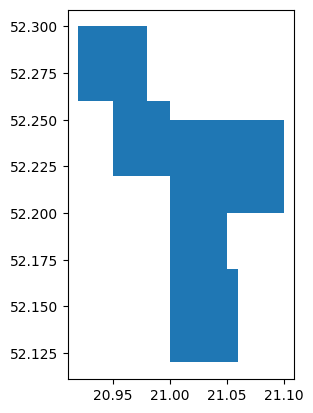

In [6]:
gminy.plot()

## 2. Układy współrzędnych (CRS)

- **`.crs`** — jaki układ ma warstwa **teraz** (metadana, nic nie liczy).
- **`.to_crs(...)`** — faktyczna **reprojekcja** współrzędnych; zwraca
  nowy `GeoDataFrame`.
- **`.set_crs(...)`** — tylko **oznaczenie** istniejących współrzędnych
  jako danego układu, bez przeliczania — używane, gdy współrzędne są
  poprawne, ale metadana CRS jest błędna/brak jej (typowe po ręcznym
  zbudowaniu `GeoDataFrame`, jeśli pominiesz `crs=` przy tworzeniu).

### Które EPSG kiedy (najczęstsze w polskim projekcie QGIS/Python)

| EPSG | Nazwa | Kiedy |
|---|---|---|
| **4326** | WGS84, geograficzny (stopnie) | wymiana danych, GPS, CSV ze współrzędnymi |
| **2180** | PUWG 1992, metryczny | analizy w Polsce: powierzchnia, długość, bufor w metrach |
| **3857** | Web Mercator, metryczny (zniekształcony) | kafle podkładowe: OSM/Google/`.explore()`/QGIS XYZ Tiles |
| **4258** | ETRS89, geograficzny | dane urzędowe UE (często zamiennie z 4326) |

**Dlaczego to ma znaczenie**: EPSG:4326 jest wygodny do przechowywania, ale
jednostki to **stopnie, nie metry** — `.buffer(100)` na danych w 4326 zrobi
bufor 100 *stopni*. Do buforów/odległości/powierzchni reprojektuj najpierw
do 2180.

In [7]:
print("CRS wejściowy:", lokalizacje.crs)

lokalizacje_2180 = lokalizacje.to_crs(epsg=2180)
gminy_2180 = gminy.to_crs(epsg=2180)
strefy_2180 = strefy.to_crs(epsg=2180)

print("współrzędne w 4326 (stopnie):", lokalizacje.geometry.iloc[0].coords[:])
print("współrzędne w 2180 (metry)  :", lokalizacje_2180.geometry.iloc[0].coords[:])

CRS wejściowy: EPSG:4326
współrzędne w 4326 (stopnie): [(21.02739233746429, 52.15639025691559)]
współrzędne w 2180 (metry)  : [(638647.2986975182, 478635.8473987002)]


## 3. Podstawowe atrybuty geometrii

Liczone bezpośrednio na kolumnie `geometry`, zawsze w jednostkach
**aktualnego CRS** — dlatego liczymy tutaj na warstwie `_2180` (metry), nie
na oryginalnej w 4326 (sekcja 2).

In [8]:
gminy_2180["powierzchnia_km2"] = gminy_2180.area / 1_000_000
gminy_2180["obwod_km"] = gminy_2180.length / 1_000
gminy_2180["typ_geometrii"] = gminy_2180.geom_type

gminy_2180[["nazwa", "powierzchnia_km2", "obwod_km", "typ_geometrii"]]

,nazwa,powierzchnia_km2,obwod_km,typ_geometrii
0,Srodmiescie,6.835264,10.770338,Polygon
1,Mokotow,19.003881,17.956674,Polygon
2,Wola,15.187503,15.725264,Polygon
3,Praga-Poludnie,26.588135,20.684371,Polygon
4,Ursynow,22.830117,19.332759,Polygon
5,Bielany,18.208519,17.083405,Polygon


## 4. Centroidy i punkt reprezentatywny

- **`.centroid`** — geometryczny środek ciężkości; dla poligonów o
  nietypowym kształcie (podkowa, pierścień) może wypaść **poza** samą
  geometrię.
- **`.representative_point()`** — punkt zagwarantowany **wewnątrz**
  geometrii (odpowiednik narzędzia QGIS "Punkt na powierzchni" / *Point on
  Surface*) — właściwy wybór do etykiet i punktów odniesienia, gdy kształt
  może być niewypukły.

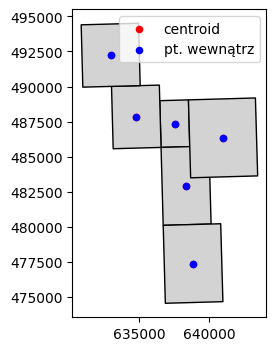

In [9]:
gminy_2180["centroid"] = gminy_2180.centroid
gminy_2180["punkt_wewnatrz"] = gminy_2180.representative_point()

ax = gminy_2180.plot(color="lightgrey", edgecolor="black", figsize=(5, 4))
gminy_2180.set_geometry("centroid").plot(ax=ax, color="red", markersize=20, label="centroid")
gminy_2180.set_geometry("punkt_wewnatrz").plot(ax=ax, color="blue", markersize=20, label="pt. wewnątrz")
ax.legend()

## 5. Odległości między punktami

- **`.distance(inna_geometria)`** — odległość para-do-pary, w jednostkach
  CRS (metry po reprojekcji do 2180).
- **Najbliższy sąsiad przez `sindex`** — bez liczenia odległości do
  każdego punktu osobno (patrz sekcja 11).
- **Macierz odległości** — dla niewielkiej liczby punktów wprost przez
  `shapely`/NumPy.
- **Odległość geodezyjna (bez reprojekcji)** — gdy interesuje Cię *rzeczywista*
  odległość po powierzchni Ziemi między punktami w 4326, a nie chcesz
  reprojektować całej warstwy, `pyproj.Geod` liczy ją bezpośrednio na
  współrzędnych geograficznych (dokładniej niż przybliżenie płaskie z 2180
  przy dużych dystansach, np. dla całego kraju).

In [10]:
a, b = lokalizacje_2180.geometry.iloc[0], lokalizacje_2180.geometry.iloc[1]
print(f"odległość punkt-punkt: {a.distance(b):.1f} m")

# najbliższy sąsiad — sindex zamiast pętli po wszystkich 400 punktach
najblizszy = lokalizacje_2180.sindex.nearest(a, return_distance=True)
print(f"najbliższy sąsiad (indeks, dystans): {najblizszy[0][1][0]}, {najblizszy[1][0]:.1f} m")

odległość punkt-punkt: 15559.7 m
najbliższy sąsiad (indeks, dystans): 0, 0.0 m


In [11]:
from pyproj import Geod

geod = Geod(ellps="WGS84")
p1, p2 = lokalizacje.geometry.iloc[0], lokalizacje.geometry.iloc[1]   # w 4326, bez reprojekcji

_, _, dystans_geodezyjny_m = geod.inv(p1.x, p1.y, p2.x, p2.y)
print(f"odległość geodezyjna (WGS84): {dystans_geodezyjny_m:.1f} m")
print(f"odległość na 2180 (płaska)  : {a.distance(b):.1f} m")

odległość geodezyjna (WGS84): 15567.0 m
odległość na 2180 (płaska)  : 15559.7 m


## 6. Siatka (grid) i zliczanie punktów w poligonach

Odpowiednik QGIS: *Create Grid* + *Count Points in Polygon* — tu jedna
technika obsługuje oba przypadki (siatka **i** realne poligony typu
gminy): spatial join punktów z poligonami, potem `groupby().size()`.

### 6a. Zliczanie w istniejących poligonach (gminy)

In [12]:
# obie warstwy mają kolumnę "nazwa" -> zmieniamy nazwę po stronie gmin przed
# joinem, żeby nie polegać na automatycznych sufiksach _left/_right
gminy_join = gminy.rename(columns={"nazwa": "nazwa_gminy"})
punkty_z_gmina = gpd.sjoin(lokalizacje, gminy_join, how="left", predicate="within")

liczba_punktow_w_gminie = (
    punkty_z_gmina.groupby("nazwa_gminy").size().rename("liczba_punktow")
)
gminy_z_liczba = gminy.merge(liczba_punktow_w_gminie, left_on="nazwa", right_index=True, how="left")
gminy_z_liczba[["nazwa", "ludnosc", "liczba_punktow"]].sort_values("liczba_punktow", ascending=False)

,nazwa,ludnosc,liczba_punktow
4,Ursynow,150000,38
3,Praga-Poludnie,190000,33
2,Wola,140000,24
5,Bielany,130000,22
1,Mokotow,220000,18
0,Srodmiescie,130000,8


### 6b. Budowa siatki (fishnet) i zliczanie w jej komórkach

Siatka to zwykła lista kwadratów `shapely.box(...)` ułożona po zasięgu
warstwy — bez gotowego narzędzia "stwórz siatkę", ale to dosłownie dwie
pętle po współrzędnych.

Text(0.5, 1.0, 'Siatka 0.02° — liczba punktów w komórce')

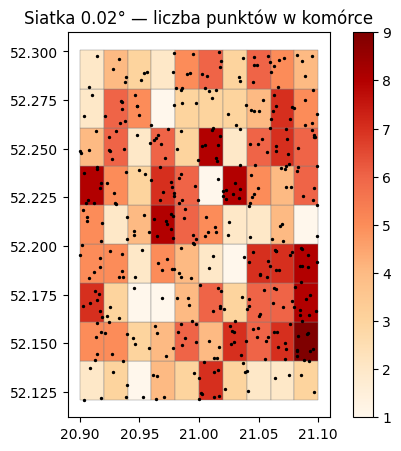

In [13]:
krok = 0.02   # rozmiar oczka siatki w stopniach (~2.2 km w tej szerokości geograficznej)
xmin, ymin, xmax, ymax = lokalizacje.total_bounds

komorki = [
    box(x, y, x + krok, y + krok)
    for x in np.arange(xmin, xmax, krok)
    for y in np.arange(ymin, ymax, krok)
]
siatka = gpd.GeoDataFrame({"id_komorki": range(len(komorki))}, geometry=komorki, crs="EPSG:4326")

punkty_z_komorka = gpd.sjoin(lokalizacje, siatka, how="left", predicate="within")
liczba_w_komorce = punkty_z_komorka.groupby("id_komorki").size().rename("n_punktow")
siatka = siatka.merge(liczba_w_komorce, on="id_komorki", how="left").fillna({"n_punktow": 0})

ax = siatka.plot(column="n_punktow", cmap="OrRd", edgecolor="grey", linewidth=0.3, legend=True, figsize=(6, 5))
lokalizacje.plot(ax=ax, color="black", markersize=2)
ax.set_title(f"Siatka {krok}° — liczba punktów w komórce")

> **Alternatywa warta znajomości: siatka heksagonalna (H3, biblioteka
> `h3`)** zamiast kwadratowej. Heksagony mają stałą odległość do środków
> sąsiednich komórek (kwadraty — nie, przekątna ≠ bok), więc lepiej nadają
> się do analiz gęstości/sąsiedztwa. `h3.latlng_to_cell(lat, lon, rozdzielczość)`
> przypisuje punkt do komórki, `h3.cell_to_boundary(...)` zwraca jej
> geometrię do zbudowania `GeoDataFrame` — ten sam dalszy `groupby().size()`.

<Axes: >

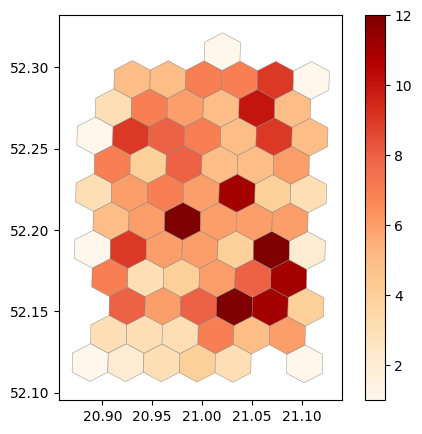

In [14]:
import h3

rozdzielczosc_h3 = 7   # im wyżej, tym mniejsze komórki — patrz dokumentacja H3 dla skali w km
lokalizacje["h3_id"] = [
    h3.latlng_to_cell(pt.y, pt.x, rozdzielczosc_h3) for pt in lokalizacje.geometry
]

liczba_w_hex = lokalizacje.groupby("h3_id").size().rename("n_punktow")
hex_ids = liczba_w_hex.index
siatka_h3 = gpd.GeoDataFrame(
    {"h3_id": hex_ids, "n_punktow": liczba_w_hex.values},
    geometry=[
        Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(h)]) for h in hex_ids
    ],
    crs="EPSG:4326",
)
siatka_h3.plot(column="n_punktow", cmap="OrRd", edgecolor="grey", linewidth=0.3, legend=True, figsize=(6, 5))

## 7. Działania na warstwach — overlay (intersection, difference, union)

Odpowiednik QGIS: *Vector > Geoprocessing Tools > Intersection / Difference
/ Union / Symmetrical Difference*. Jedna funkcja `gpd.overlay(a, b,
how=...)`, różny tylko parametr `how`.

In [15]:
przeciecie = gpd.overlay(gminy, strefy, how="intersection")
roznica = gpd.overlay(gminy, strefy, how="difference")          # gminy MINUS strefy
suma = gpd.overlay(gminy, strefy, how="union")
roznica_symetryczna = gpd.overlay(gminy, strefy, how="symmetric_difference")

print("intersection          :", len(przeciecie), "obiektów")
print("difference            :", len(roznica), "obiektów")
print("union                 :", len(suma), "obiektów")
print("symmetric_difference  :", len(roznica_symetryczna), "obiektów")

przeciecie[["nazwa", "strefa"]]   # każdy wiersz = fragment gminy realnie objęty daną strefą

intersection          : 10 obiektów
difference            : 6 obiektów
union                 : 19 obiektów
symmetric_difference  : 9 obiektów


,nazwa,strefa
0,Srodmiescie,ochrony_A
1,Srodmiescie,inwestycyjna_B
2,Srodmiescie,zielona_C
3,Mokotow,ochrony_A
4,Mokotow,inwestycyjna_B
5,Wola,ochrony_A
6,Wola,zielona_C
7,Praga-Poludnie,ochrony_A
8,Praga-Poludnie,inwestycyjna_B
9,Bielany,zielona_C


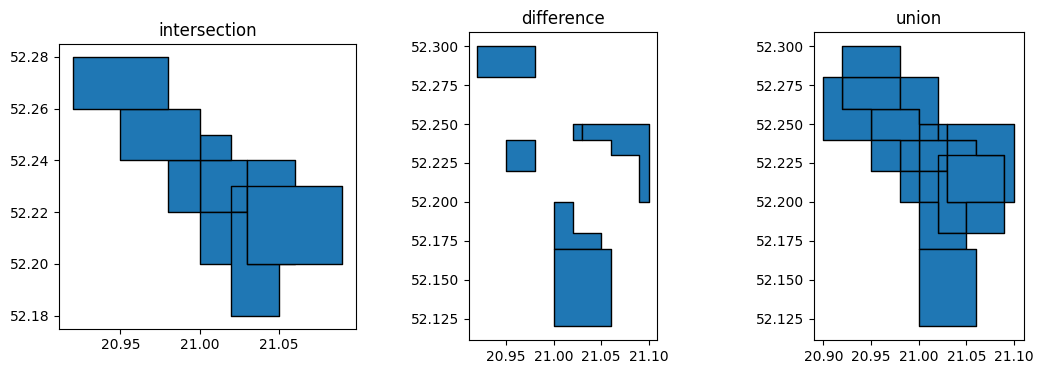

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (dane, tytul) in zip(axes, [(przeciecie, "intersection"), (roznica, "difference"), (suma, "union")]):
    dane.plot(ax=ax, edgecolor="black")
    ax.set_title(tytul)

## 8. Łączenie (scalanie) warstw wektorowych

Dwie różne operacje, obie nazywane potocznie "złączeniem", warto rozróżniać:

### 8a. Scalenie kilku warstw tego samego typu w jedną (QGIS: *Merge Vector Layers*)

Zwykła konkatenacja wierszy — geometrie zostają, jakie były, nic nie jest
przecinane/łączone geometrycznie (to robi dopiero `overlay`/`dissolve`).

In [17]:
gminy_polnoc = gminy.iloc[[0, 4]]
gminy_poludnie = gminy.iloc[[1, 2, 3, 5]]

scalone = gpd.GeoDataFrame(pd.concat([gminy_polnoc, gminy_poludnie], ignore_index=True), crs=gminy.crs)
print(len(scalone), "wierszy po scaleniu (tyle samo co w oryginale — sama konkatenacja)")

6 wierszy po scaleniu (tyle samo co w oryginale — sama konkatenacja)


### 8b. Złączenie atrybutowe po wspólnym polu — bez związku przestrzennego

(QGIS: *Join Attributes by Field Value*) — zwykły `pandas.merge`, dokłada
kolumny z tabeli bez geometrii po wspólnym kluczu. Kontrast z sekcją 9
(złączenie **wg lokalizacji**, bez wspólnego klucza, tylko na podstawie
geometrii).

In [18]:
lokalizacje_z_opisem = lokalizacje.merge(opisy_kategorii, on="kategoria", how="left")
lokalizacje_z_opisem[["id_punktu", "kategoria", "opis", "stawka_podatku"]].head(3)

,id_punktu,kategoria,opis,stawka_podatku
0,1,biuro,biuro administracyjne,0.19
1,2,biuro,biuro administracyjne,0.19
2,3,magazyn,magazyn/centrum dystrybucji,0.08


## 9. Złączanie warstw wg lokalizacji (spatial join)

(QGIS: *Join Attributes by Location*) — `gpd.sjoin(...)`, relację określa
`predicate`: `"within"` (punkt w poligonie), `"intersects"`,
`"contains"`, `"dwithin"` (w zadanej odległości od geometrii). **Obie
warstwy muszą być w tym samym CRS** — inaczej wynik będzie błędny albo po
cichu pusty.

Osobny wariant — `gpd.sjoin_nearest(...)` (QGIS: *Join Attributes by
Nearest*) — łączy z **najbliższym** obiektem, nawet gdy żaden nie spełnia
`within`/`intersects` (np. najbliższa gmina do punktu leżącego tuż poza
jej granicą).

In [19]:
# within — ten sam sjoin co w sekcji 6a (punkty_z_gmina); tu tylko sprawdzenie skuteczności złączenia
print("przypisanych do gminy:", punkty_z_gmina["nazwa_gminy"].notna().sum(), "z", len(lokalizacje))

# sjoin_nearest — zawsze znajdzie dopasowanie, nawet dla punktów poza wszystkimi poligonami
punkty_najblizsza_strefa = gpd.sjoin_nearest(
    lokalizacje_2180, strefy_2180, distance_col="odleglosc_do_strefy_m"
)
punkty_najblizsza_strefa[["id_punktu", "strefa", "odleglosc_do_strefy_m"]].sort_values("odleglosc_do_strefy_m").head()

przypisanych do gminy: 143 z 400


,id_punktu,strefa,odleglosc_do_strefy_m
391,392,inwestycyjna_B,0.0
11,12,zielona_C,0.0
388,389,inwestycyjna_B,0.0
9,10,inwestycyjna_B,0.0
15,16,zielona_C,0.0


## 10. Agregacja na warstwach

Dwie sytuacje, oba dostępne z poziomu tabeli atrybutów QGIS:

### 10a. Agregacja ze scaleniem geometrii — `dissolve` (QGIS: *Dissolve*,
z opcją statystyk pól)

Grupuje po kolumnie, **łączy geometrie** w grupie w jedną (np. gminy w
województwo) i jednocześnie liczy zadane statystyki na pozostałych
kolumnach.

In [20]:
wojewodztwa = gminy.dissolve(
    by="wojewodztwo",
    aggfunc={"ludnosc": "sum", "nazwa": lambda s: ", ".join(s)},
)
wojewodztwa

,geometry,ludnosc,nazwa
wojewodztwo,,,
mazowieckie,"POLYGON ((21.06 52.12, 21 52.12, 21 52.17, 21 ...",960000,"Srodmiescie, Mokotow, Wola, Praga-Poludnie, Ur..."


### 10b. Agregacja bez scalania geometrii (QGIS: funkcja `aggregate()` w
kalkulatorze pól / *Join by Location (summary)*)

Liczba wierszy **zostaje bez zmian** — do każdego wiersza dokładana jest
wartość policzona dla całej jego grupy (odpowiednik funkcji okna w SQL:
`SUM(...) OVER (PARTITION BY ...)`).

In [21]:
punkty_z_gmina["suma_sprzedazy_w_gminie"] = (
    punkty_z_gmina.groupby("nazwa_gminy")["wartosc_sprzedazy"].transform("sum")
)
punkty_z_gmina["udzial_w_gminie_pct"] = (
    100 * punkty_z_gmina["wartosc_sprzedazy"] / punkty_z_gmina["suma_sprzedazy_w_gminie"]
)

# liczba wierszy identyczna jak w `lokalizacje` — to nie jest dissolve
punkty_z_gmina[["id_punktu", "nazwa_gminy", "wartosc_sprzedazy", "suma_sprzedazy_w_gminie", "udzial_w_gminie_pct"]].head()

,id_punktu,nazwa_gminy,wartosc_sprzedazy,suma_sprzedazy_w_gminie,udzial_w_gminie_pct
0,1,Ursynow,888.51,38757.58,2.292481
1,2,Bielany,3218.91,21279.03,15.127146
2,3,NaN,215.81,NaN,NaN
3,4,NaN,773.83,NaN,NaN
4,5,NaN,285.84,NaN,NaN


## 11. Wydajność przy większych zbiorach

- **`pyogrio`** — szybszy silnik I/O niż `fiona` (sprawdzone na starcie
  notebooka).
- **Odczyt fragmentu pliku** — `read_file(..., bbox=...)` czyta z dysku
  tylko geometrie przecinające zadany obszar, bez wczytywania całego pliku.
- **`.sindex`** — indeks przestrzenny (R-tree), budowany automatycznie w
  `sjoin`/`sjoin_nearest`/`clip`; przy własnych, powtarzanych zapytaniach
  warto użyć go jawnie (`sindex.query(...)`) zamiast liczyć relację do
  każdej geometrii w pętli.
- **`.simplify(tolerancja)`** — upraszcza geometrię (mniej wierzchołków) do
  szybszego renderowania/eksportu, gdy dokładność co do metra nie ma
  znaczenia (np. podgląd, warstwa tła na mapie interaktywnej).

In [22]:
fragment = gpd.read_file(dane_dir / "warstwy.gpkg", layer="gminy", bbox=(21.00, 52.20, 21.05, 52.24))
print(f"z bbox: {len(fragment)} z {len(gpd.read_file(dane_dir / 'warstwy.gpkg', layer='gminy'))} wierszy")

uproszczone = gminy_2180.simplify(50)   # tolerancja w metrach (CRS = 2180)
print("wierzchołki przed/po uproszczeniu (przykładowy poligon):",
      len(gminy_2180.geometry.iloc[0].exterior.coords), "/", len(uproszczone.iloc[0].exterior.coords))

z bbox: 4 z 6 wierszy
wierzchołki przed/po uproszczeniu (przykładowy poligon): 5 / 5


## 12. Częste pułapki

- **CRS mismatch przy `sjoin`/`overlay`** — GeoPandas nie reprojektuje
  automatycznie; zawsze `assert a.crs == b.crs` albo jawny `.to_crs()`
  przed operacją.
- **Nieprawidłowe geometrie** — `.is_valid` do sprawdzenia, `.make_valid()`
  do naprawy przed `overlay`/`union`, które na złej geometrii rzucą błąd
  albo dadzą zły wynik.
- **`Polygon` vs `MultiPolygon`** — ten sam obiekt logiczny bywa raz
  pojedynczy, raz wielokrotny (np. wyspa jako osobna część tej samej
  gminy); filtr po `geom_type == "Polygon"` cicho zgubi te drugie.
  `.explode(index_parts=False)` rozbija je na osobne wiersze.

In [23]:
print("wszystkie geometrie poprawne:", gminy.geometry.is_valid.all())

gminy_pojedyncze = gminy.explode(index_parts=False)
print("wierszy przed/po explode:", len(gminy), "/", len(gminy_pojedyncze))

wszystkie geometrie poprawne: True
wierszy przed/po explode: 6 / 6


## 13. Zaskocz mnie — łączenie z innymi bibliotekami

### scikit-learn — klastrowanie przestrzenne (DBSCAN)

Klasyczny problem "jak pogrupować punkty w skupiska bez z góry zadanej
liczby grup" (QGIS ma do tego algorytm *DBSCAN Clustering*) — w Pythonie
to jedna linia `scikit-learn` na współrzędnych z warstwy metrycznej
(`eps` w metrach ma wtedy bezpośrednią interpretację, inaczej niż w
stopniach z 4326). Wart poznania, bo łączy dwie rzeczy z Twojej ścieżki
rozwoju naraz — geoanalizę i ML — jednym wywołaniem.

liczba klastrów (bez szumu -1): 20
punkty uznane za szum (-1)   : 200


<Axes: >

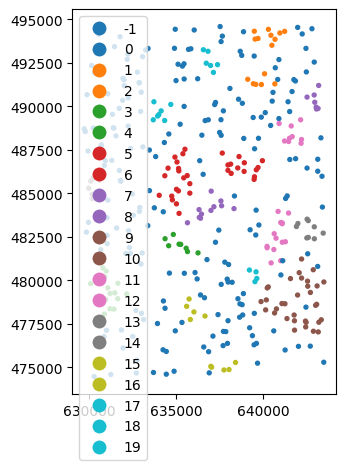

In [24]:
from sklearn.cluster import DBSCAN

wspolrzedne = np.column_stack([lokalizacje_2180.geometry.x, lokalizacje_2180.geometry.y])

etykiety = DBSCAN(eps=800, min_samples=5).fit_predict(wspolrzedne)   # eps w metrach (CRS = 2180)
lokalizacje_2180["klaster"] = etykiety

print("liczba klastrów (bez szumu -1):", len(set(etykiety) - {-1}))
print("punkty uznane za szum (-1)   :", (etykiety == -1).sum())

lokalizacje_2180.plot(column="klaster", categorical=True, legend=True, markersize=8, figsize=(5, 5))

### GeoParquet — nowoczesny format wymiany, zamiast SHP/GPKG

Parquet z zachowaną geometrią i CRS w metadanych — kolumnowy, dobrze
skompresowany, i (kluczowe w Twoim stacku) **czytany bezpośrednio przez
DuckDB** (`spatial` extension, patrz osobny notebook o DuckDB) bez
przechodzenia przez GeoPandas — sensowny format pośredni w pipeline: ciężka
obróbka atrybutowa w DuckDB/Polars, geometria "jedzie obok" bez utraty
informacji o układzie współrzędnych.

In [25]:
gminy.to_parquet(dane_dir / "gminy.parquet")   # GeoParquet — wymaga pyarrow

wczytane = gpd.read_parquet(dane_dir / "gminy.parquet")
print("CRS zachowany w metadanych pliku:", wczytane.crs)

CRS zachowany w metadanych pliku: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit":

### Inne warte odnotowania (kod referencyjny — wymaga sieci, nie wykonywany tutaj)

- **`contextily`** — dokłada kafle OSM/inne jako tło pod statyczny
  `.plot()` (matplotlib) — najbliższy odpowiednik widoku mapy z QGIS w
  samym notebooku, bez `.explore()`.
- **DuckDB `spatial`** — przy bardzo dużych joinach przestrzennych
  (miliony geometrii) bywa szybszy niż `gpd.sjoin`; sensowny wzorzec to
  ciężki join w DuckDB SQL, wynik (już przefiltrowany) wczytany do
  GeoPandas tylko do wizualizacji/edycji w QGIS.

In [26]:
# import contextily as cx
# ax = gminy_2180.to_crs(epsg=3857).plot(alpha=0.5, edgecolor="black", figsize=(6, 5))
# cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)   # EPSG:3857 wymagany przez kafle

# duckdb.sql("INSTALL spatial; LOAD spatial;")
# duckdb.sql("""
#     SELECT p.*, g.nazwa
#     FROM read_parquet('lokalizacje.parquet') AS p
#     JOIN ST_Read('gminy.gpkg') AS g ON ST_Within(ST_Point(p.lon, p.lat), g.geom)
# """).df()

## 14. Zapisywanie wyników

Do GPKG zawsze warto podać `layer=` — bez tego domyślna nazwa warstwy
bierze się z nazwy pliku, co bywa mylące przy wielu zapisach do tego
samego pliku.

In [27]:
siatka.to_file(dane_dir / "warstwy.gpkg", layer="siatka_zliczenia", driver="GPKG")
punkty_z_gmina.drop(columns=["index_right"]).to_file(
    dane_dir / "warstwy.gpkg", layer="punkty_z_agregacja", driver="GPKG"
)

print("warstwy w warstwy.gpkg:", gpd.list_layers(dane_dir / "warstwy.gpkg")["name"].tolist())

warstwy w warstwy.gpkg: ['gminy', 'strefy', 'siatka_zliczenia', 'punkty_z_agregacja']


## 15. Wizualizacja — kolorowanie po atrybucie, wiele warstw, mapa interaktywna

Text(0.5, 1.0, 'Gminy (wg ludności) + strefy (kontur) + lokalizacje')

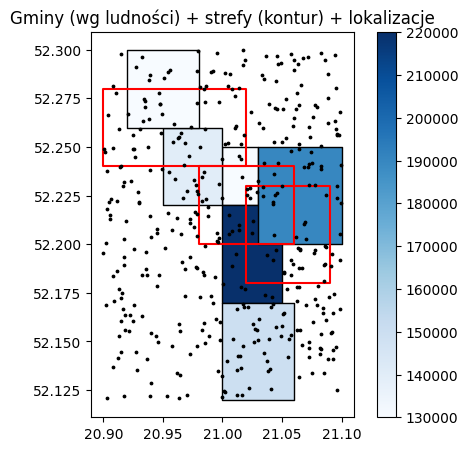

In [28]:
ax = gminy.plot(column="ludnosc", cmap="Blues", legend=True, edgecolor="black", figsize=(6, 5))
strefy.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=1.5)
lokalizacje.plot(ax=ax, color="black", markersize=3)
ax.set_title("Gminy (wg ludności) + strefy (kontur) + lokalizacje")

In [29]:
# interaktywna mapa (Folium/Leaflet pod spodem) — bliższe QGIS-owemu podglądowi,
# ale bez wychodzenia z notebooka; wymaga wyświetlenia w środowisku z HTML
# m = gminy.explore(column="ludnosc", cmap="Blues", tooltip="nazwa")
# lokalizacje.explore(m=m, color="black", marker_kwds={"radius": 3})
print("gpd.explore() — patrz komentarz wyżej")

gpd.explore() — patrz komentarz wyżej


In [30]:
# porządki po demie
import shutil
shutil.rmtree(dane_dir, ignore_errors=True)
print("posprzątane:", not dane_dir.exists())

posprzątane: True
